In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as si
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

Para el péndulo simple escalado las ecuaciones son:
$$
\dot \theta = v_{\theta}
$$
$$
\dot v_{\theta} = - \sin(\theta)
$$
con variables $(\theta, v_{\theta})$ y la energía escalada:
$$
\varepsilon = \frac{\dot \theta ^2}{2} + (1-\cos(\theta))
$$

In [4]:
def pendulo(t,th_vth):
    return np.array([th_vth[1] , -np.sin(th_vth[0]) ])

def E_pendulo(th_vth):
    return 0.5*th_vth[1]**2 + (1-np.cos(th_vth[0]))

def th2xy(th_vth):
    x = sin(th_vth[0])
    y = -cos(th_vth[0])
    return  np.array([x,y])

In [37]:
ci = [0.1,0]
titf = (0,100)
sol_pendulo = si.solve_ivp(pendulo,titf,ci,rtol=1e-8,atol=1e-10,dense_output=True)

0.0049958347219741794 0.004995833184506592 1.537467587270358e-09


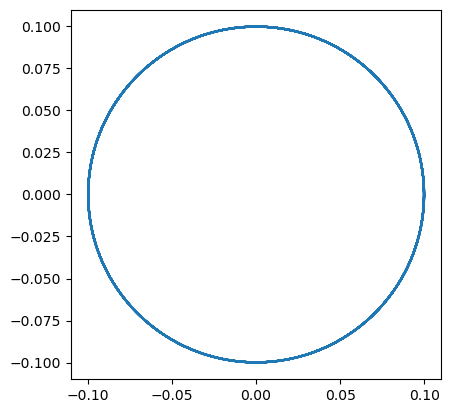

In [43]:
t = np.linspace(titf[0],titf[-1],1000)
th_vth = sol_pendulo.sol(t)
E = E_pendulo(th_vth)
print(E[0] , E[-1] , abs(E[0] - E[-1]) )
plt.plot(th_vth[0],th_vth[1])
plt.gca().set_aspect('equal')
plt.show()

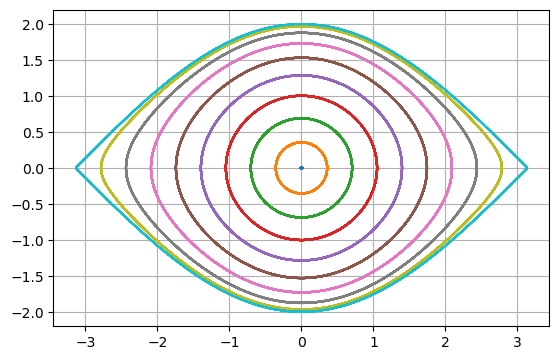

In [46]:
titf = (0,100)
t = np.linspace(titf[0],titf[-1],1000)
N_tray = 10
th0 = np.linspace(1e-2,np.pi-1e-2,N_tray)
for i in range(N_tray):
    ci = [th0[i],0]
    sol_pendulo = si.solve_ivp(pendulo,titf,ci,rtol=1e-8,atol=1e-10,dense_output=True)
    th_vth = sol_pendulo.sol(t)
    plt.plot(th_vth[0],th_vth[1])
plt.gca().set_aspect('equal')
plt.grid()
plt.show()

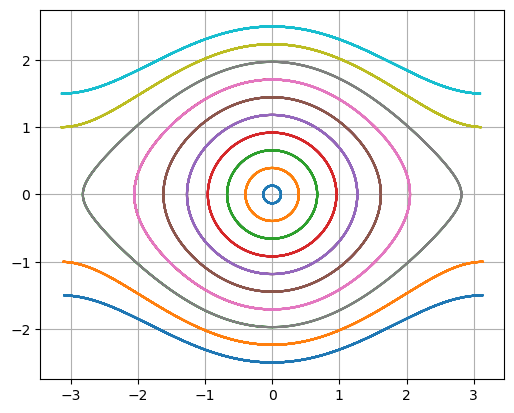

In [93]:
titf = (0,30)
t = np.linspace(titf[0],titf[-1],1000)
N_tray = 20
vth0 = np.linspace(-2.5,2.5,N_tray)
for i in range(N_tray):
    ci = [0,vth0[i]]
    sol_pendulo = si.solve_ivp(pendulo,titf,ci,rtol=1e-8,atol=1e-10,dense_output=True)
    th_vth = sol_pendulo.sol(t)
    if vth0[i] > 2:
        th_p = (th_vth[0] + np.pi)%(2*np.pi) - np.pi
        th_p[:-1][ np.diff( th_p) <0 ] = np.nan
        plt.plot(th_p,th_vth[1])
    elif vth0[i] < -2:
        th_p = (th_vth[0] + np.pi)%(2*np.pi) - np.pi
        th_p[:-1][ np.diff( th_p) > 0 ] = np.nan
        plt.plot(th_p,th_vth[1])
    else:
        plt.plot(th_vth[0],th_vth[1])
plt.gca().set_aspect('equal')
plt.grid()
plt.show()

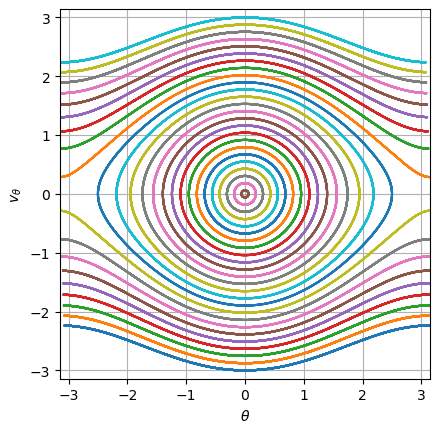

In [100]:
titf = (0,30)
t = np.linspace(titf[0],titf[-1],1000)
N_tray = 50
vth0 = np.linspace(-3,3,N_tray)
for i in range(N_tray):
    ci = [0,vth0[i]]
    sol_pendulo = si.solve_ivp(pendulo,titf,ci,rtol=1e-8,atol=1e-10,dense_output=True)
    th_vth = sol_pendulo.sol(t)
    if abs(vth0[i]) > 2:
        th_p = (th_vth[0] + np.pi)%(2*np.pi) - np.pi
        th_p[:-1][ abs(np.diff( th_p)) > 0.5 ] = np.nan
        plt.plot(th_p,th_vth[1])
    else:
        plt.plot(th_vth[0],th_vth[1])
plt.gca().set_aspect('equal')
plt.xlabel(r'${\theta}$'),plt.ylabel(r'$v_{\theta}$')
plt.xlim([-np.pi,np.pi]),plt.ylim([-np.pi,np.pi])
plt.grid()
plt.show()